In [ ]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
from collections import defaultdict
import re
import seaborn as sns
import warnings
from scipy import signal
from scipy.stats import skew, kurtosis

warnings.filterwarnings('ignore')

In [ ]:
# --- PUT THIS NEAR THE TOP (with your imports) ---
import torch
import os

checkpoint_dir = './logs/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Also initialize your tracking variable before the loop starts
best_val_loss = float('inf')

In [ ]:
data_path = Path.home() / "sleep-edf-database-expanded-1.0.0" / "sleep-edf-database-expanded-1.0.0" / "sleep-cassette"
print(f"Data path: {data_path}")
print(f"Path exists: {data_path.exists()}")

Data path: /home/gella.saikrishna/sleep-edf-database-expanded-1.0.0/sleep-edf-database-expanded-1.0.0/sleep-cassette
Path exists: True


In [ ]:
edf_files = list(data_path.glob("*.edf"))
print(f"\nFound {len(edf_files)} EDF files")
for f in edf_files[:10]:  # Show first 10
    print(f"  {f.name}")


Found 306 EDF files
  SC4291GA-Hypnogram.edf
  SC4581GM-Hypnogram.edf
  SC4241E0-PSG.edf
  SC4722E0-PSG.edf
  SC4612E0-PSG.edf
  SC4491G0-PSG.edf
  SC4181EC-Hypnogram.edf
  SC4812GV-Hypnogram.edf
  SC4722EM-Hypnogram.edf
  SC4052E0-PSG.edf


In [ ]:
import re
import pandas as pd
from pathlib import Path
from collections import defaultdict

# Set up data path
data_path = Path.home() / "sleep-edf-database-expanded-1.0.0" / "sleep-edf-database-expanded-1.0.0" / "sleep-cassette"

# List all EDF files
edf_files = list(data_path.glob("*.edf"))

def parse_participant_info(filename):
    """
    Parse participant ID and recording day from filename
    Format: SCxxxx-XXX.edf where:
    - SC is prefix
    - xxxx: first 3 digits = participant ID, last digit = day number
    - PSG or Hypnogram indicates file type
    """
    name = filename.stem

    # Extract the SCxxxx part
    match = re.match(r'(SC\d{4})', name)
    if not match:
        return None

    sc_part = match.group(1)  # e.g., "SC4001"
    participant_num = int(sc_part[2:5])  # First 3 digits after SC (e.g., 400)
    day = int(sc_part[5])  # Last digit (e.g., 1)

    # Determine file type
    if 'Hypnogram' in name:
        file_type = 'hypnogram'
    elif 'PSG' in name:
        file_type = 'psg'
    else:
        file_type = 'other'

    return {
        'participant_id': f"SC{participant_num:03d}",
        'participant_num': participant_num,
        'day': day,
        'type': file_type,
        'filename': filename.name
    }

# Collect all participant information
participant_data = defaultdict(lambda: defaultdict(dict))

for edf_file in edf_files:
    info = parse_participant_info(edf_file)
    if info:
        pid = info['participant_id']
        day = info['day']
        file_type = info['type']
        participant_data[pid][day][file_type] = info['filename']

# Display results
print("\n" + "="*80)
print("SLEEP-EDF DATASET SUMMARY STATISTICS")
print("="*80)

# Basic counts
total_participants = len(participant_data)
total_psg_files = sum(1 for f in edf_files if 'PSG' in f.name)
total_hypno_files = sum(1 for f in edf_files if 'Hypnogram' in f.name)

print(f"\n📊 DATASET OVERVIEW")
print(f"   Total EDF files: {len(edf_files)}")
print(f"   PSG files: {total_psg_files}")
print(f"   Hypnogram files: {total_hypno_files}")
print(f"   Unique participants: {total_participants}")

# Count participants by day availability
day1_only = 0
day2_only = 0
both_days = 0
has_day1 = 0
has_day2 = 0

for pid, days in participant_data.items():
    has_day1_flag = 1 in days
    has_day2_flag = 2 in days

    if has_day1_flag:
        has_day1 += 1
    if has_day2_flag:
        has_day2 += 1

    if has_day1_flag and has_day2_flag:
        both_days += 1
    elif has_day1_flag and not has_day2_flag:
        day1_only += 1
    elif has_day2_flag and not has_day1_flag:
        day2_only += 1

print(f"\n📅 DAY AVAILABILITY")
print(f"   Participants with Day 1 data: {has_day1}")
print(f"   Participants with Day 2 data: {has_day2}")
print(f"   Participants with only Day 1: {day1_only}")
print(f"   Participants with only Day 2: {day2_only}")
print(f"   Participants with BOTH days: {both_days}")

# Hypnogram availability
hypnogram_stats = defaultdict(lambda: {'day1': False, 'day2': False})

for pid, days in participant_data.items():
    for day in days:
        if 'hypnogram' in days[day]:
            hypnogram_stats[pid][f'day{day}'] = True

participants_with_any_hypnogram = sum(1 for stats in hypnogram_stats.values() if stats['day1'] or stats['day2'])
participants_with_both_days_hypnogram = sum(1 for stats in hypnogram_stats.values() if stats['day1'] and stats['day2'])

day1_hypnogram = sum(1 for stats in hypnogram_stats.values() if stats['day1'])
day2_hypnogram = sum(1 for stats in hypnogram_stats.values() if stats['day2'])

print(f"\n📋 HYPNOGRAM AVAILABILITY")
print(f"   Participants with hypnogram (any day): {participants_with_any_hypnogram}")
print(f"   Day 1 hypnogram: {day1_hypnogram} participants")
print(f"   Day 2 hypnogram: {day2_hypnogram} participants")
print(f"   Participants with hypnogram for BOTH days: {participants_with_both_days_hypnogram}")

# Complete data (PSG + Hypnogram)
complete_day1 = 0
complete_day2 = 0
complete_both = 0

for pid, days in participant_data.items():
    day1_complete = False
    day2_complete = False

    if 1 in days:
        if 'psg' in days[1] and 'hypnogram' in days[1]:
            complete_day1 += 1
            day1_complete = True
    if 2 in days:
        if 'psg' in days[2] and 'hypnogram' in days[2]:
            complete_day2 += 1
            day2_complete = True

    if day1_complete and day2_complete:
        complete_both += 1

print(f"\n✅ COMPLETE DATA (PSG + Hypnogram)")
print(f"   Day 1 complete: {complete_day1} participants")
print(f"   Day 2 complete: {complete_day2} participants")
print(f"   Both days complete: {complete_both} participants")

# Create detailed dataframe
detailed_data = []
for pid, days in sorted(participant_data.items()):
    participant_num = int(pid[2:])  # Extract number after SC

    row = {
        'Participant_ID': pid,
        'Participant_Num': participant_num,
        'Has_Day1': 1 in days,
        'Has_Day2': 2 in days,
        'Day1_PSG': days.get(1, {}).get('psg', 'No'),
        'Day1_Hypnogram': days.get(1, {}).get('hypnogram', 'No'),
        'Day2_PSG': days.get(2, {}).get('psg', 'No'),
        'Day2_Hypnogram': days.get(2, {}).get('hypnogram', 'No'),
    }
    detailed_data.append(row)

df = pd.DataFrame(detailed_data)
df = df.sort_values('Participant_Num')

# Save to CSV
output_file = data_path / "sleep_edf_participant_summary.csv"
df.to_csv(output_file, index=False)

print(f"\n💾 Detailed participant data saved to: {output_file}")

# Final summary table
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

summary_data = {
    'Metric': [
        'Total Participants',
        'Total PSG Files',
        'Total Hypnogram Files',
        'Participants with Day 1',
        'Participants with Day 2',
        'Participants with Both Days',
        'Participants with Day 1 Hypnogram',
        'Participants with Day 2 Hypnogram',
        'Participants with Complete Day 1',
        'Participants with Complete Day 2',
        'Participants with Complete Both Days'
    ],
    'Count': [
        total_participants,
        total_psg_files,
        total_hypno_files,
        has_day1,
        has_day2,
        both_days,
        day1_hypnogram,
        day2_hypnogram,
        complete_day1,
        complete_day2,
        complete_both
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print(f"✅ Analysis complete! Processed {total_participants} participants")
print("="*80)


SLEEP-EDF DATASET SUMMARY STATISTICS

📊 DATASET OVERVIEW
   Total EDF files: 306
   PSG files: 153
   Hypnogram files: 153
   Unique participants: 78

📅 DAY AVAILABILITY
   Participants with Day 1 data: 76
   Participants with Day 2 data: 77
   Participants with only Day 1: 1
   Participants with only Day 2: 2
   Participants with BOTH days: 75

📋 HYPNOGRAM AVAILABILITY
   Participants with hypnogram (any day): 78
   Day 1 hypnogram: 76 participants
   Day 2 hypnogram: 77 participants
   Participants with hypnogram for BOTH days: 75

✅ COMPLETE DATA (PSG + Hypnogram)
   Day 1 complete: 76 participants
   Day 2 complete: 77 participants
   Both days complete: 75 participants

💾 Detailed participant data saved to: /home/gella.saikrishna/sleep-edf-database-expanded-1.0.0/sleep-edf-database-expanded-1.0.0/sleep-cassette/sleep_edf_participant_summary.csv

FINAL SUMMARY
                              Metric  Count
                  Total Participants     78
                     Total PSG Fil

In [ ]:
only_day1 = [pid for pid, days in participant_data.items() if 1 in days and 2 not in days]
only_day2 = [pid for pid, days in participant_data.items() if 2 in days and 1 not in days]

print(f"\nParticipants with ONLY Day-1 data ({len(only_day1)}): {sorted(only_day1)}")
print(f"\nParticipants with ONLY Day-2 data ({len(only_day2)}): {sorted(only_day2)}")


Participants with ONLY Day-1 data (1): ['SC413']

Participants with ONLY Day-2 data (2): ['SC436', 'SC452']


In [ ]:
# Get the first participant and output all channel names
first_participant = list(participant_data.keys())[0]
day1_data = participant_data[first_participant].get(1, {})
psg_file = day1_data.get('psg', None)

if psg_file:
    psg_path = data_path / psg_file
    raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)

    print(f"\nParticipant: {first_participant}")
    print(f"File: {psg_file}")
    print(f"\nAll channel names ({len(raw.ch_names)} channels):")
    print("="*50)
    for i, ch in enumerate(raw.ch_names, 1):
        print(f"{i:3d}. {ch}")
else:
    print(f"No PSG file found for {first_participant}")


Participant: SC429
File: SC4291G0-PSG.edf

All channel names (7 channels):
  1. EEG Fpz-Cz
  2. EEG Pz-Oz
  3. EOG horizontal
  4. Resp oro-nasal
  5. EMG submental
  6. Temp rectal
  7. Event marker



ANALYZING PARTICIPANT: SC400

PSG File: SC4001E0-PSG.edf
Hypnogram File: SC4001EC-Hypnogram.edf

ALL AVAILABLE CHANNELS WITH INDICES
  [ 0] EEG Fpz-Cz
  [ 1] EEG Pz-Oz
  [ 2] EOG horizontal
  [ 3] Resp oro-nasal
  [ 4] EMG submental
  [ 5] Temp rectal
  [ 6] Event marker

SELECTED CHANNELS
EEG Fpz-Cz: [0] EEG Fpz-Cz
EEG Pz-Oz: [1] EEG Pz-Oz
EMG: [4] EMG submental

RECORDING PARAMETERS
Sampling frequency: 100.0 Hz
Duration: 22.08 hours (1325.0 minutes)
Total samples: 7,950,000

DATA VERIFICATION
EEG1 - Min: -192.00 uV, Max: 170.62 uV, Std: 25.91 uV
EEG2 - Min: -171.09 uV, Max: 196.00 uV, Std: 11.43 uV
EMG - Min: -0.51 uV, Max: 3.91 uV, Std: 0.96 uV

EPOCH INFORMATION
Epoch duration: 30 seconds
Epoch samples: 3,000
Total PSG epochs: 2650

HYPNOGRAM LOADED
Total hypnogram epochs: 2650
Sleep stages present: ['Wake', 'N1', 'N2', 'N3', 'N4', 'REM']

Sleep stage distribution:
  Wake: 1997 epochs (75.4%)
  N1: 58 epochs (2.2%)
  N2: 250 epochs (9.4%)
  N3: 101 epochs (3.8%)
  N4: 119 epochs (

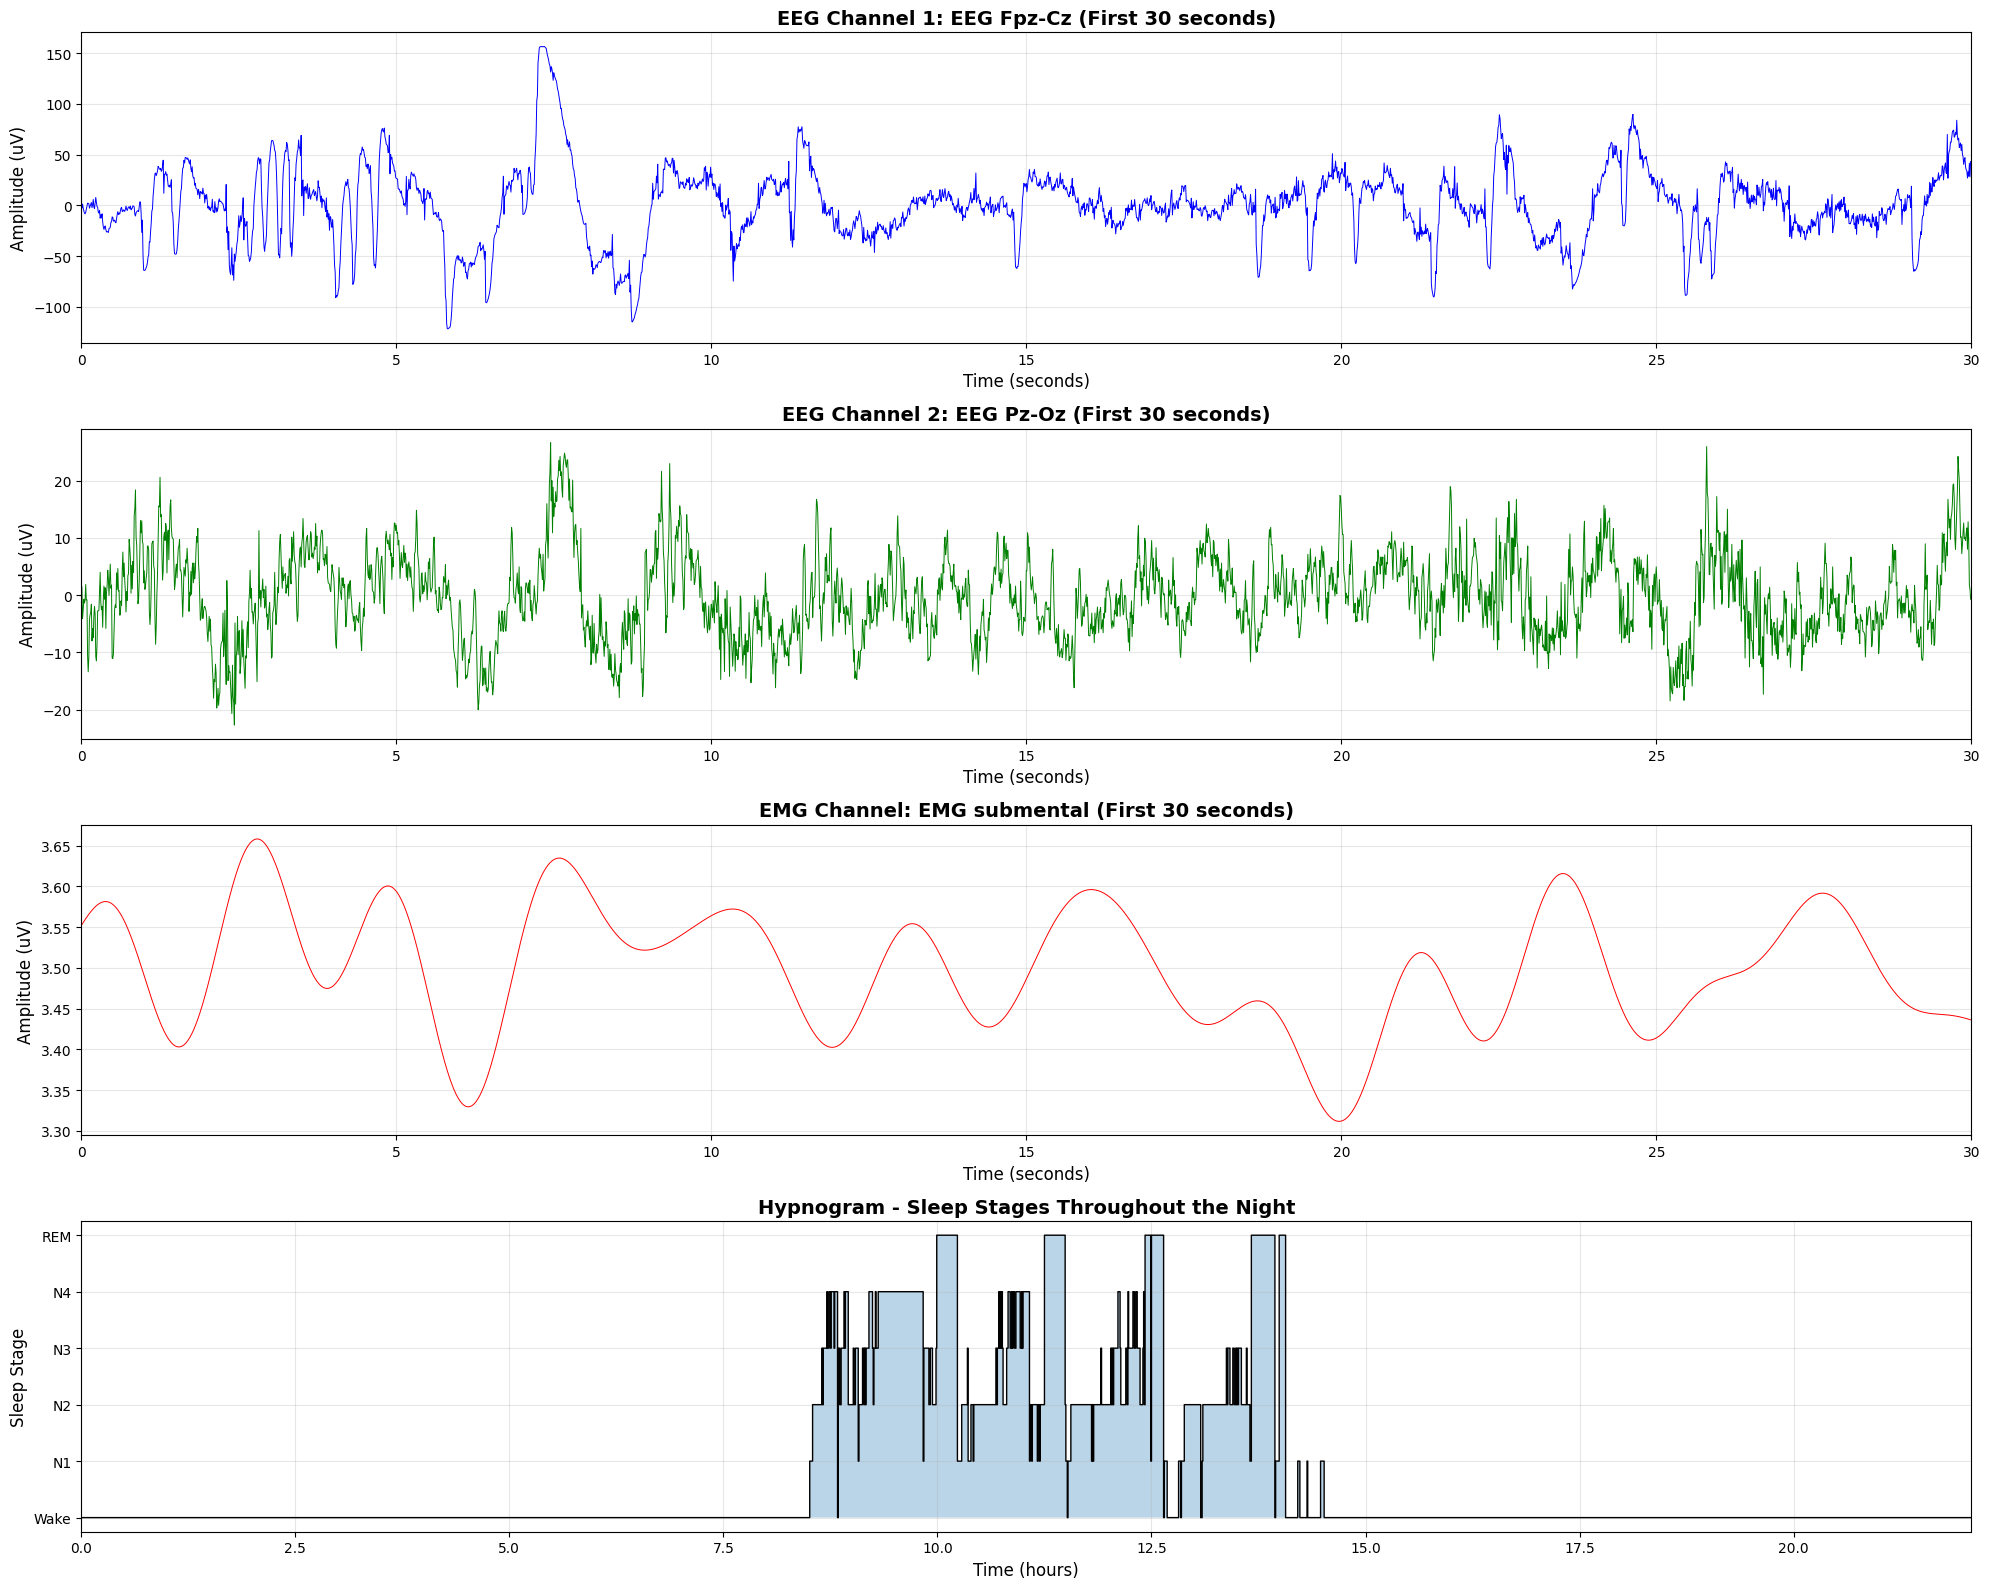

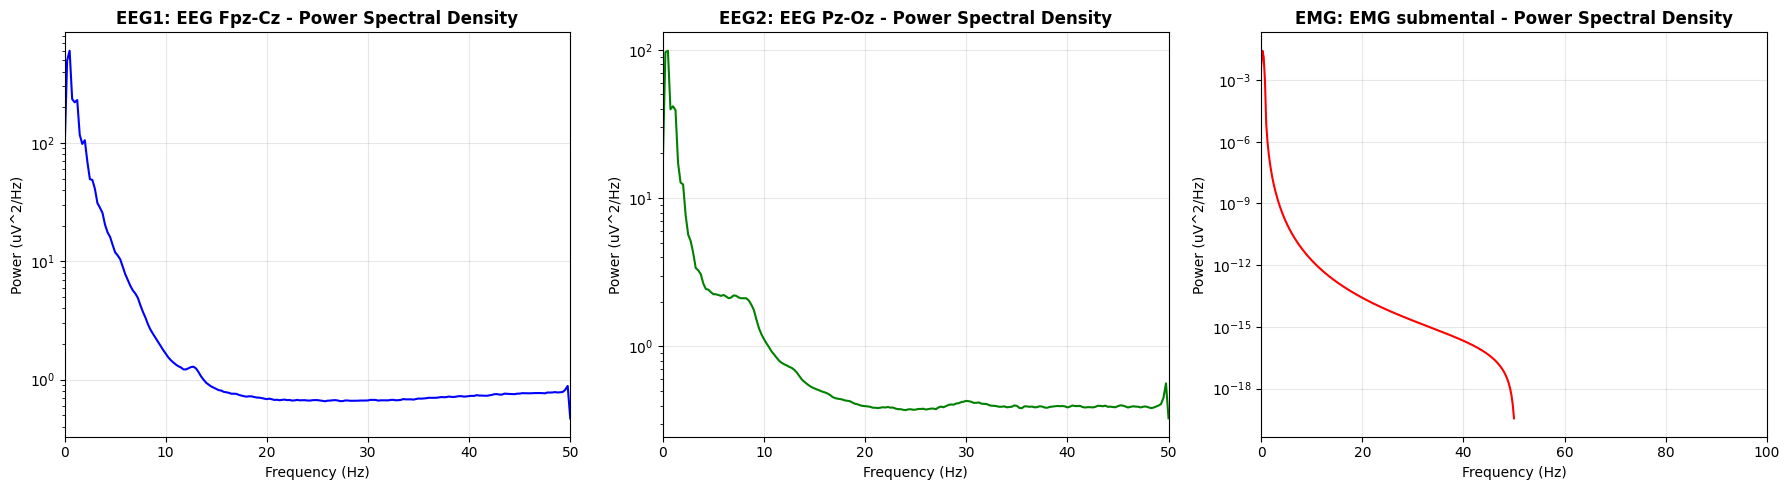


SIGNAL STATISTICS

EEG Fpz-Cz:
  Mean: 0.17 uV
  Std: 25.91 uV
  RMS: 25.91 uV
  Min: -192.00 uV
  Max: 170.62 uV
  Peak-to-Peak: 362.62 uV

EEG Pz-Oz:
  Mean: -0.35 uV
  Std: 11.43 uV
  RMS: 11.43 uV
  Min: -171.09 uV
  Max: 196.00 uV
  Peak-to-Peak: 367.09 uV

EMG submental:
  Mean: 2.95 uV
  Std: 0.96 uV
  RMS: 3.10 uV
  Min: -0.51 uV
  Max: 3.91 uV
  Peak-to-Peak: 4.42 uV

Analysis complete for participant SC400


In [ ]:
first_participant = "SC400"

print(f"\n{'=' * 80}")
print(f"ANALYZING PARTICIPANT: {first_participant}")
print(f"{'=' * 80}")

day1_data = participant_data[first_participant].get(1, {})
psg_file = day1_data.get("psg")
hypno_file = day1_data.get("hypnogram")

stage_name_to_code = {
    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 4,
    "Sleep stage R": 5,
    "Sleep stage ?": -1,
    "Movement time": -2,
}

stage_code_to_name = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "N4",
    5: "REM",
    -1: "Unknown",
    -2: "Movement",
}


def find_channel(raw, preferred_names, fallback_keywords):
    channels = raw.ch_names
    lower_channels = [ch.lower() for ch in channels]

    for preferred in preferred_names:
        preferred_lower = preferred.lower()
        for idx, ch_lower in enumerate(lower_channels):
            if preferred_lower == ch_lower:
                return idx

    for preferred in preferred_names:
        preferred_lower = preferred.lower()
        for idx, ch_lower in enumerate(lower_channels):
            if preferred_lower in ch_lower:
                return idx

    for keywords in fallback_keywords:
        for idx, ch_lower in enumerate(lower_channels):
            if all(keyword.lower() in ch_lower for keyword in keywords):
                return idx

    return None


def get_channel_data_uv(raw, idx):
    if idx is None:
        return None
    return raw.get_data(picks=[idx])[0] * 1e6


def print_signal_check(label, data):
    if data is None:
        print(f"{label}: not available")
        return

    print(
        f"{label} - "
        f"Min: {np.min(data):.2f} uV, "
        f"Max: {np.max(data):.2f} uV, "
        f"Std: {np.std(data):.2f} uV"
    )


def load_hypnogram_annotations(hypno_path, epoch_duration=30):
    annotations = mne.read_annotations(hypno_path)

    hypno_epochs = []

    for description, duration in zip(annotations.description, annotations.duration):
        stage_code = stage_name_to_code.get(description)

        if stage_code is None:
            continue

        n_epochs_for_annotation = int(round(duration / epoch_duration))

        if n_epochs_for_annotation > 0:
            hypno_epochs.extend([stage_code] * n_epochs_for_annotation)

    if len(hypno_epochs) == 0:
        return None

    return np.array(hypno_epochs, dtype=int)


def print_signal_statistics(channel_name, data):
    if data is None or len(data) == 0 or not np.isfinite(data).any():
        print(f"\nNo valid data found for {channel_name}")
        return

    if np.std(data) == 0:
        print(f"\n{channel_name}: data is flat/all zeros")
        return

    print(f"\n{channel_name}:")
    print(f"  Mean: {np.mean(data):.2f} uV")
    print(f"  Std: {np.std(data):.2f} uV")
    print(f"  RMS: {np.sqrt(np.mean(data ** 2)):.2f} uV")
    print(f"  Min: {np.min(data):.2f} uV")
    print(f"  Max: {np.max(data):.2f} uV")
    print(f"  Peak-to-Peak: {np.ptp(data):.2f} uV")


if psg_file:
    print(f"\nPSG File: {psg_file}")
    print(f"Hypnogram File: {hypno_file if hypno_file else 'Not available'}")

    psg_path = data_path / psg_file
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)

    all_channels = raw.ch_names

    print(f"\n{'=' * 60}")
    print("ALL AVAILABLE CHANNELS WITH INDICES")
    print(f"{'=' * 60}")

    for i, ch in enumerate(all_channels):
        print(f"  [{i:2d}] {ch}")

    eeg_fpz_cz_idx = find_channel(
        raw,
        preferred_names=["EEG Fpz-Cz", "Fpz-Cz"],
        fallback_keywords=[["fpz", "cz"], ["eeg"]],
    )

    eeg_pz_oz_idx = find_channel(
        raw,
        preferred_names=["EEG Pz-Oz", "Pz-Oz"],
        fallback_keywords=[["pz", "oz"]],
    )

    emg_idx = find_channel(
        raw,
        preferred_names=["EMG submental", "EMG"],
        fallback_keywords=[["emg"], ["submental"]],
    )

    if eeg_pz_oz_idx == eeg_fpz_cz_idx:
        eeg_pz_oz_idx = None
        for idx, ch in enumerate(all_channels):
            ch_lower = ch.lower()
            if idx != eeg_fpz_cz_idx and ("eeg" in ch_lower or "pz" in ch_lower or "oz" in ch_lower):
                eeg_pz_oz_idx = idx
                break

    print(f"\nSELECTED CHANNELS")
    print(
        f"EEG Fpz-Cz: "
        f"[{eeg_fpz_cz_idx}] {all_channels[eeg_fpz_cz_idx]}"
        if eeg_fpz_cz_idx is not None
        else "EEG Fpz-Cz: not found"
    )
    print(
        f"EEG Pz-Oz: "
        f"[{eeg_pz_oz_idx}] {all_channels[eeg_pz_oz_idx]}"
        if eeg_pz_oz_idx is not None
        else "EEG Pz-Oz: not found"
    )
    print(
        f"EMG: "
        f"[{emg_idx}] {all_channels[emg_idx]}"
        if emg_idx is not None
        else "EMG: not found"
    )

    sfreq = float(raw.info["sfreq"])
    duration_hours = raw.times[-1] / 3600
    n_samples = raw.n_times

    print(f"\nRECORDING PARAMETERS")
    print(f"Sampling frequency: {sfreq} Hz")
    print(f"Duration: {duration_hours:.2f} hours ({duration_hours * 60:.1f} minutes)")
    print(f"Total samples: {n_samples:,}")

    eeg1_data = get_channel_data_uv(raw, eeg_fpz_cz_idx)
    eeg2_data = get_channel_data_uv(raw, eeg_pz_oz_idx)
    emg_data = get_channel_data_uv(raw, emg_idx)

    print(f"\nDATA VERIFICATION")
    print_signal_check("EEG1", eeg1_data)
    print_signal_check("EEG2", eeg2_data)
    print_signal_check("EMG", emg_data)

    epoch_duration = 30
    epoch_samples = int(epoch_duration * sfreq)
    n_epochs = n_samples // epoch_samples

    print(f"\nEPOCH INFORMATION")
    print(f"Epoch duration: {epoch_duration} seconds")
    print(f"Epoch samples: {epoch_samples:,}")
    print(f"Total PSG epochs: {n_epochs}")

    hypno_data = None

    if hypno_file:
        try:
            hypno_path = data_path / hypno_file
            hypno_data = load_hypnogram_annotations(hypno_path, epoch_duration=epoch_duration)

            if hypno_data is None or len(hypno_data) == 0:
                print("\nCould not load hypnogram file: no valid sleep-stage annotations found")
            else:
                if len(hypno_data) > n_epochs:
                    hypno_data = hypno_data[:n_epochs]

                print(f"\nHYPNOGRAM LOADED")
                print(f"Total hypnogram epochs: {len(hypno_data)}")

                unique_stages = np.unique(hypno_data)
                print(
                    "Sleep stages present: "
                    f"{[stage_code_to_name.get(int(s), f'Stage_{int(s)}') for s in unique_stages]}"
                )

                print("\nSleep stage distribution:")
                for stage in unique_stages:
                    count = np.sum(hypno_data == stage)
                    percentage = (count / len(hypno_data)) * 100
                    stage_name = stage_code_to_name.get(int(stage), f"Stage_{int(stage)}")
                    print(f"  {stage_name}: {count} epochs ({percentage:.1f}%)")

        except Exception as e:
            print(f"\nCould not load hypnogram file: {e}")

    fig = plt.figure(figsize=(20, 16))

    ax1 = plt.subplot(4, 1, 1)
    if eeg1_data is not None and np.std(eeg1_data) > 0:
        plot_samples = min(int(30 * sfreq), len(eeg1_data))
        time = np.arange(plot_samples) / sfreq
        ax1.plot(time, eeg1_data[:plot_samples], "b-", linewidth=0.7)
        ax1.set_title(
            f"EEG Channel 1: {all_channels[eeg_fpz_cz_idx]} (First 30 seconds)",
            fontsize=14,
            fontweight="bold",
        )
        ax1.set_xlabel("Time (seconds)", fontsize=12)
        ax1.set_ylabel("Amplitude (uV)", fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(0, min(30, plot_samples / sfreq))
    else:
        channel_text = all_channels[eeg_fpz_cz_idx] if eeg_fpz_cz_idx is not None else "None"
        ax1.text(
            0.5,
            0.5,
            f"EEG Channel 1 data not available or all zeros\nChannel: {channel_text}",
            ha="center",
            va="center",
            transform=ax1.transAxes,
            fontsize=12,
        )

    ax2 = plt.subplot(4, 1, 2)
    if eeg2_data is not None and np.std(eeg2_data) > 0:
        plot_samples = min(int(30 * sfreq), len(eeg2_data))
        time = np.arange(plot_samples) / sfreq
        ax2.plot(time, eeg2_data[:plot_samples], "g-", linewidth=0.7)
        ax2.set_title(
            f"EEG Channel 2: {all_channels[eeg_pz_oz_idx]} (First 30 seconds)",
            fontsize=14,
            fontweight="bold",
        )
        ax2.set_xlabel("Time (seconds)", fontsize=12)
        ax2.set_ylabel("Amplitude (uV)", fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, min(30, plot_samples / sfreq))
    else:
        channel_text = all_channels[eeg_pz_oz_idx] if eeg_pz_oz_idx is not None else "None"
        ax2.text(
            0.5,
            0.5,
            f"EEG Channel 2 data not available or all zeros\nChannel: {channel_text}",
            ha="center",
            va="center",
            transform=ax2.transAxes,
            fontsize=12,
        )

    ax3 = plt.subplot(4, 1, 3)
    if emg_data is not None and np.std(emg_data) > 0:
        plot_samples = min(int(30 * sfreq), len(emg_data))
        time = np.arange(plot_samples) / sfreq
        ax3.plot(time, emg_data[:plot_samples], "r-", linewidth=0.7)
        ax3.set_title(
            f"EMG Channel: {all_channels[emg_idx]} (First 30 seconds)",
            fontsize=14,
            fontweight="bold",
        )
        ax3.set_xlabel("Time (seconds)", fontsize=12)
        ax3.set_ylabel("Amplitude (uV)", fontsize=12)
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim(0, min(30, plot_samples / sfreq))
    else:
        channel_text = all_channels[emg_idx] if emg_idx is not None else "None"
        ax3.text(
            0.5,
            0.5,
            f"EMG data not available or all zeros\nChannel: {channel_text}",
            ha="center",
            va="center",
            transform=ax3.transAxes,
            fontsize=12,
        )

    ax4 = plt.subplot(4, 1, 4)
    if hypno_data is not None and len(hypno_data) > 0:
        unique_stages = np.unique(hypno_data)
        epoch_times = np.arange(len(hypno_data)) * epoch_duration / 3600

        ax4.step(epoch_times, hypno_data, where="post", color="black", linewidth=1)
        ax4.fill_between(epoch_times, hypno_data, step="post", alpha=0.3)
        ax4.set_title("Hypnogram - Sleep Stages Throughout the Night", fontsize=14, fontweight="bold")
        ax4.set_xlabel("Time (hours)", fontsize=12)
        ax4.set_ylabel("Sleep Stage", fontsize=12)
        ax4.grid(True, alpha=0.3)
        ax4.set_yticks(list(unique_stages))
        ax4.set_yticklabels([stage_code_to_name.get(int(s), f"S{int(s)}") for s in unique_stages])
        ax4.set_xlim(0, epoch_times[-1] if len(epoch_times) > 0 else 0)
    else:
        ax4.text(
            0.5,
            0.5,
            "Hypnogram data not available",
            ha="center",
            va="center",
            transform=ax4.transAxes,
            fontsize=12,
        )

    plt.tight_layout()
    plt.show()

    if eeg1_data is not None and np.std(eeg1_data) > 0:
        fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

        nperseg = int(min(sfreq * 4, len(eeg1_data)))
        freqs1, psd1 = signal.welch(eeg1_data, fs=sfreq, nperseg=nperseg)
        axes[0].semilogy(freqs1, psd1, "b-", linewidth=1.5)
        axes[0].set_title(
            f"EEG1: {all_channels[eeg_fpz_cz_idx]} - Power Spectral Density",
            fontsize=12,
            fontweight="bold",
        )
        axes[0].set_xlabel("Frequency (Hz)", fontsize=10)
        axes[0].set_ylabel("Power (uV^2/Hz)", fontsize=10)
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlim(0, 50)

        if eeg2_data is not None and np.std(eeg2_data) > 0:
            nperseg = int(min(sfreq * 4, len(eeg2_data)))
            freqs2, psd2 = signal.welch(eeg2_data, fs=sfreq, nperseg=nperseg)
            axes[1].semilogy(freqs2, psd2, "g-", linewidth=1.5)
            axes[1].set_title(
                f"EEG2: {all_channels[eeg_pz_oz_idx]} - Power Spectral Density",
                fontsize=12,
                fontweight="bold",
            )
            axes[1].set_xlabel("Frequency (Hz)", fontsize=10)
            axes[1].set_ylabel("Power (uV^2/Hz)", fontsize=10)
            axes[1].grid(True, alpha=0.3)
            axes[1].set_xlim(0, 50)
        else:
            axes[1].text(0.5, 0.5, "EEG2 not available", ha="center", va="center")
            axes[1].set_axis_off()

        if emg_data is not None and np.std(emg_data) > 0:
            nperseg = int(min(sfreq * 4, len(emg_data)))
            freqs3, psd3 = signal.welch(emg_data, fs=sfreq, nperseg=nperseg)
            axes[2].semilogy(freqs3, psd3, "r-", linewidth=1.5)
            axes[2].set_title(
                f"EMG: {all_channels[emg_idx]} - Power Spectral Density",
                fontsize=12,
                fontweight="bold",
            )
            axes[2].set_xlabel("Frequency (Hz)", fontsize=10)
            axes[2].set_ylabel("Power (uV^2/Hz)", fontsize=10)
            axes[2].grid(True, alpha=0.3)
            axes[2].set_xlim(0, 100)
        else:
            axes[2].text(0.5, 0.5, "EMG not available", ha="center", va="center")
            axes[2].set_axis_off()

        plt.tight_layout()
        plt.show()

    print(f"\n{'=' * 80}")
    print("SIGNAL STATISTICS")
    print(f"{'=' * 80}")

    eeg1_name = all_channels[eeg_fpz_cz_idx] if eeg_fpz_cz_idx is not None else "EEG1"
    eeg2_name = all_channels[eeg_pz_oz_idx] if eeg_pz_oz_idx is not None else "EEG2"
    emg_name = all_channels[emg_idx] if emg_idx is not None else "EMG"

    print_signal_statistics(eeg1_name, eeg1_data)
    print_signal_statistics(eeg2_name, eeg2_data)
    print_signal_statistics(emg_name, emg_data)

    print(f"\n{'=' * 80}")
    print(f"Analysis complete for participant {first_participant}")
    print(f"{'=' * 80}")

else:
    print(f"No PSG file found for participant {first_participant}")

In [ ]:
from pathlib import Path
import json
import numpy as np
import mne

SERVER_SAVE_DIR = Path("/home/gella.saikrishna/code/Manual/saved_sleep_edf")
NORMALIZED_SAVE_DIR = SERVER_SAVE_DIR / "normalized_psg"

NORMALIZED_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Normalized data will be saved in: {NORMALIZED_SAVE_DIR}")

Normalized data will be saved in: /home/gella.saikrishna/code/Manual/saved_sleep_edf/normalized_psg


In [ ]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def safe_file_name(participant, day, psg_file):
    psg_stem = Path(psg_file).stem
    return f"{participant}_day{day}_{psg_stem}.npz"


def save_normalized_to_disk(save_path, psg_entry, stats_entry, hypno_entry):
    metadata = {
        "participant": psg_entry["participant"],
        "day": psg_entry["day"],
        "psg_file": psg_entry["psg_file"],
        "channel_names": psg_entry["channel_names"],
        "sfreq": psg_entry["sfreq"],
        "stats": make_json_safe(stats_entry),
        "hypnogram_file": hypno_entry.get("hypnogram_file"),
    }

    hypnogram = hypno_entry.get("hypnogram")

    temp_path = save_path.with_name(save_path.stem + "_tmp.npz")

    np.savez_compressed(
        temp_path,
        normalized_data=psg_entry["normalized_data"].astype(np.float32),
        hypnogram=hypnogram if hypnogram is not None else np.array([], dtype=np.int64),
        metadata=np.array(json.dumps(metadata), dtype=object),
    )

    temp_path.replace(save_path)


def load_normalized_from_disk(load_path):
    saved = np.load(load_path, allow_pickle=True)

    metadata = json.loads(str(saved["metadata"].item()))
    hypnogram = saved["hypnogram"]

    if len(hypnogram) == 0:
        hypnogram = None

    key = (metadata["participant"], metadata["day"])

    psg_entry = {
        "participant": metadata["participant"],
        "day": metadata["day"],
        "psg_file": metadata["psg_file"],
        "channel_names": metadata["channel_names"],
        "sfreq": metadata["sfreq"],
        "normalized_data": saved["normalized_data"],
    }

    stats_entry = metadata.get("stats", {})

    hypno_entry = {
        "participant": metadata["participant"],
        "day": metadata["day"],
        "hypnogram_file": metadata.get("hypnogram_file"),
        "hypnogram": hypnogram,
    }

    return key, psg_entry, stats_entry, hypno_entry

In [ ]:
RUN_NORMALIZATION = False

if RUN_NORMALIZATION:
    normalized_psg_data = {}
    psg_normalization_stats = {}
    hypnogram_data = {}

    for file_number, record in enumerate(psg_file_records, start=1):
        participant = record["participant"]
        day = record["day"]
        psg_file = record["psg"]
        hypno_file = record["hypnogram"]

        save_path = NORMALIZED_SAVE_DIR / safe_file_name(participant, day, psg_file)

        if save_path.exists():
            print(f"\n[{file_number}/{len(psg_file_records)}] Already saved on server, loading: {save_path.name}")

            key, psg_entry, stats_entry, hypno_entry = load_normalized_from_disk(save_path)

            normalized_psg_data[key] = psg_entry
            psg_normalization_stats[key] = stats_entry
            hypnogram_data[key] = hypno_entry

            continue

        print(f"\n[{file_number}/{len(psg_file_records)}] Normalizing PSG and saving to server: {psg_file}")

        psg_path = data_path / psg_file
        raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)

        normalized_data, stats = normalize_single_psg_file(raw)

        key = (participant, day)

        psg_entry = {
            "participant": participant,
            "day": day,
            "psg_file": psg_file,
            "channel_names": raw.ch_names,
            "sfreq": float(raw.info["sfreq"]),
            "normalized_data": normalized_data,
        }

        stats_entry = {
            "participant": participant,
            "day": day,
            "psg_file": psg_file,
            "channel_stats": stats,
        }

        hypno_entry = {
            "participant": participant,
            "day": day,
            "hypnogram_file": hypno_file,
            "hypnogram": None,
        }

        if hypno_file:
            try:
                hypno_path = data_path / hypno_file
                hypno = load_hypnogram_annotations(hypno_path, epoch_duration=epoch_duration)
                hypno_entry["hypnogram"] = hypno

                if hypno is None:
                    print("  Hypnogram loaded unchanged: no valid sleep-stage annotations found")
                else:
                    print(f"  Hypnogram loaded unchanged: {len(hypno)} epochs")

            except Exception as e:
                print(f"  Could not load hypnogram, left untouched: {e}")

        save_normalized_to_disk(
            save_path=save_path,
            psg_entry=psg_entry,
            stats_entry=stats_entry,
            hypno_entry=hypno_entry,
        )

        print(f"  Saved to server disk: {save_path}")

        normalized_psg_data[key] = psg_entry
        psg_normalization_stats[key] = stats_entry
        hypnogram_data[key] = hypno_entry

        raw.close()

    print(f"\n{'=' * 80}")
    print("NORMALIZATION COMPLETE")
    print(f"{'=' * 80}")
    print(f"PSG files available in RAM: {len(normalized_psg_data)}")
    print(f"PSG files saved on server disk: {len(list(NORMALIZED_SAVE_DIR.glob('*.npz')))}")
    print(f"Saved directory: {NORMALIZED_SAVE_DIR}")
else:
    print("Skipping normalization because RUN_NORMALIZATION = False")

Skipping normalization because RUN_NORMALIZATION = False


In [ ]:
from pathlib import Path
import json
import numpy as np

NORMALIZED_SAVE_DIR = Path("/home/gella.saikrishna/code/Manual/saved_sleep_edf/normalized_psg")


def load_normalized_from_disk(load_path):
    saved = np.load(load_path, allow_pickle=True)

    metadata = json.loads(str(saved["metadata"].item()))
    hypnogram = saved["hypnogram"]

    if len(hypnogram) == 0:
        hypnogram = None

    participant = metadata["participant"]
    day = metadata["day"]
    key = (participant, day)

    psg_entry = {
        "participant": participant,
        "day": day,
        "psg_file": metadata["psg_file"],
        "channel_names": metadata["channel_names"],
        "sfreq": metadata["sfreq"],
        "normalized_data": saved["normalized_data"],
    }

    stats_entry = metadata.get("stats", {})

    hypno_entry = {
        "participant": participant,
        "day": day,
        "hypnogram_file": metadata.get("hypnogram_file"),
        "hypnogram": hypnogram,
    }

    return key, psg_entry, stats_entry, hypno_entry


normalized_psg_data = {}
psg_normalization_stats = {}
hypnogram_data = {}

saved_files = sorted(NORMALIZED_SAVE_DIR.glob("*.npz"))

print(f"Saved normalized PSG files found: {len(saved_files)}")

if len(saved_files) == 0:
    raise FileNotFoundError(f"No saved normalized files found in {NORMALIZED_SAVE_DIR}")

for load_path in saved_files:
    key, psg_entry, stats_entry, hypno_entry = load_normalized_from_disk(load_path)

    normalized_psg_data[key] = psg_entry
    psg_normalization_stats[key] = stats_entry
    hypnogram_data[key] = hypno_entry

print(f"Loaded normalized PSG files: {len(normalized_psg_data)}")
print(f"Loaded hypnograms: {len(hypnogram_data)}")

Saved normalized PSG files found: 153
Loaded normalized PSG files: 153
Loaded hypnograms: 153


In [ ]:
from sklearn.model_selection import train_test_split

test_size = 0.2
random_state = 42

all_participants = sorted(set(key[0] for key in normalized_psg_data.keys()))

train_participants, test_participants = train_test_split(
    all_participants,
    test_size=test_size,
    random_state=random_state,
    shuffle=True,
)

train_participants = sorted(train_participants)
test_participants = sorted(test_participants)

print(f"Total participants: {len(all_participants)}")
print(f"Train participants: {len(train_participants)}")
print(f"Test participants: {len(test_participants)}")

print("\nTrain participants:")
print(train_participants)

print("\nTest participants:")
print(test_participants)

Total participants: 78
Train participants: 62
Test participants: 16

Train participants:
['SC401', 'SC402', 'SC403', 'SC405', 'SC406', 'SC407', 'SC408', 'SC409', 'SC411', 'SC413', 'SC414', 'SC415', 'SC416', 'SC417', 'SC419', 'SC420', 'SC421', 'SC423', 'SC424', 'SC425', 'SC426', 'SC427', 'SC428', 'SC429', 'SC431', 'SC432', 'SC435', 'SC436', 'SC437', 'SC438', 'SC440', 'SC441', 'SC442', 'SC443', 'SC444', 'SC446', 'SC447', 'SC448', 'SC449', 'SC451', 'SC452', 'SC453', 'SC454', 'SC456', 'SC457', 'SC458', 'SC459', 'SC460', 'SC461', 'SC463', 'SC464', 'SC465', 'SC466', 'SC470', 'SC471', 'SC472', 'SC473', 'SC474', 'SC476', 'SC477', 'SC480', 'SC481']

Test participants:
['SC400', 'SC404', 'SC410', 'SC412', 'SC418', 'SC422', 'SC430', 'SC433', 'SC434', 'SC445', 'SC450', 'SC455', 'SC462', 'SC467', 'SC475', 'SC482']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=7,
            stride=stride,
            padding=3,
            bias=False,
        )
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=7,
            stride=1,
            padding=3,
            bias=False,
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.dropout = nn.Dropout(dropout)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm1d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + residual
        out = F.relu(out)

        return out


class SleepResNet1D(nn.Module):
    def __init__(self, n_channels=3, n_classes=6, dropout=0.2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(
                n_channels,
                64,
                kernel_size=15,
                stride=2,
                padding=7,
                bias=False,
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = nn.Sequential(
            ResidualBlock1D(64, 64, stride=1, dropout=dropout),
            ResidualBlock1D(64, 64, stride=1, dropout=dropout),
        )

        self.layer2 = nn.Sequential(
            ResidualBlock1D(64, 128, stride=2, dropout=dropout),
            ResidualBlock1D(128, 128, stride=1, dropout=dropout),
        )

        self.layer3 = nn.Sequential(
            ResidualBlock1D(128, 256, stride=2, dropout=dropout),
            ResidualBlock1D(256, 256, stride=1, dropout=dropout),
        )

        self.layer4 = nn.Sequential(
            ResidualBlock1D(256, 512, stride=2, dropout=dropout),
            ResidualBlock1D(512, 512, stride=1, dropout=dropout),
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.global_pool(x)
        x = self.classifier(x)

        return x

In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip cache purge
!pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Files removed: 48 (2982.6 MB)
Directories removed: 0
Looking in indexes: https://download.pytorch.org/whl/cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 768.4/768.4 MB 22.6 MB/s  0:00:17m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 13.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 19.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchaudio]3 [torchaudio]]


In [ ]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.6.0+cu124
True
12.4
NVIDIA RTX A4000


In [ ]:
import os
import torch

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU name: NVIDIA RTX A4000


In [ ]:
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

selected_channels = ["EEG Fpz-Cz", "EEG Pz-Oz", "EMG submental"]
epoch_duration = 30


def get_channel_index(channel_names, target_name):
    target_lower = target_name.lower()

    for idx, ch in enumerate(channel_names):
        if ch.lower() == target_lower:
            return idx

    for idx, ch in enumerate(channel_names):
        if target_lower in ch.lower():
            return idx

    return None


def make_epochs_from_psg_entry(psg_entry, hypno_entry, selected_channels, epoch_duration=30):
    normalized_data = psg_entry["normalized_data"]
    channel_names = psg_entry["channel_names"]
    sfreq = psg_entry["sfreq"]
    hypnogram = hypno_entry["hypnogram"]

    if hypnogram is None:
        return None, None

    channel_indices = []

    for channel_name in selected_channels:
        idx = get_channel_index(channel_names, channel_name)

        if idx is None:
            print(f"Missing channel {channel_name} in {psg_entry['psg_file']}")
            return None, None

        channel_indices.append(idx)

    selected_data = normalized_data[channel_indices]

    samples_per_epoch = int(sfreq * epoch_duration)
    n_signal_epochs = selected_data.shape[1] // samples_per_epoch
    n_hypno_epochs = len(hypnogram)

    n_epochs = min(n_signal_epochs, n_hypno_epochs)

    selected_data = selected_data[:, :n_epochs * samples_per_epoch]

    selected_data = selected_data.reshape(
        len(selected_channels),
        n_epochs,
        samples_per_epoch,
    )

    X = np.transpose(selected_data, (1, 0, 2))
    y = np.array(hypnogram[:n_epochs], dtype=np.int64)

    valid_mask = y >= 0

    X = X[valid_mask]
    y = y[valid_mask]

    return X, y


X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

for key, psg_entry in normalized_psg_data.items():
    participant = key[0]

    if key not in hypnogram_data:
        continue

    hypno_entry = hypnogram_data[key]

    X, y = make_epochs_from_psg_entry(
        psg_entry=psg_entry,
        hypno_entry=hypno_entry,
        selected_channels=selected_channels,
        epoch_duration=epoch_duration,
    )

    if X is None or y is None:
        continue

    if participant in train_participants:
        X_train_list.append(X)
        y_train_list.append(y)

    elif participant in test_participants:
        X_test_list.append(X)
        y_test_list.append(y)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTrain labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))

X_train shape: (327570, 3, 3000)
y_train shape: (327570,)
X_test shape: (87391, 3, 3000)
y_test shape: (87391,)

Train labels: (array([0, 1, 2, 3, 4, 5]), array([225220,  16971,  54453,   7290,   3033,  20603]))
Test labels: (array([0, 1, 2, 3, 4, 5]), array([60213,  4551, 14679,  1503,  1213,  5232]))


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

CHECKPOINT_DIR = Path("/home/gella.saikrishna/code/Manual/saved_sleep_edf/model_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

latest_checkpoint_path = CHECKPOINT_DIR / "latest_checkpoint.pt"
best_checkpoint_path = CHECKPOINT_DIR / "best_checkpoint.pt"

batch_size = 64
num_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = SleepResNet1D(n_channels=3, n_classes=6, dropout=0.2).to(device)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

Using device: cuda


In [ ]:
from pathlib import Path
import torch
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CHECKPOINT_DIR = Path("/home/gella.saikrishna/code/Manual/saved_sleep_edf/model_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

latest_checkpoint_path = CHECKPOINT_DIR / "latest_checkpoint.pt"
best_checkpoint_path = CHECKPOINT_DIR / "best_checkpoint.pt"

batch_size = 64
num_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

model = SleepResNet1D(
    n_channels=3,
    n_classes=6,
    dropout=0.2,
).to(device)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)


def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def save_checkpoint(
    checkpoint_path,
    epoch,
    model,
    optimizer,
    train_loss,
    test_loss,
    test_accuracy,
    best_test_accuracy,
):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "best_test_accuracy": best_test_accuracy,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
    }

    temp_path = checkpoint_path.with_name(checkpoint_path.stem + "_tmp.pt")
    torch.save(checkpoint, temp_path)
    temp_path.replace(checkpoint_path)


def load_checkpoint(checkpoint_path, model, optimizer, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_test_accuracy = checkpoint.get("best_test_accuracy", 0.0)

    return start_epoch, best_test_accuracy


start_epoch = 0
best_test_accuracy = 0.0

if latest_checkpoint_path.exists():
    start_epoch, best_test_accuracy = load_checkpoint(
        checkpoint_path=latest_checkpoint_path,
        model=model,
        optimizer=optimizer,
        device=device,
    )

    print(f"Resumed from checkpoint: {latest_checkpoint_path}")
    print(f"Starting from epoch: {start_epoch + 1}")
    print(f"Best previous test accuracy: {best_test_accuracy * 100:.2f}%")
else:
    print("No checkpoint found. Starting training from epoch 1.")


for epoch in range(start_epoch, num_epochs):
    model.train()

    running_loss = 0.0
    total_train_samples = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        total_train_samples += X_batch.size(0)

    train_loss = running_loss / total_train_samples

    test_loss, test_accuracy = evaluate_model(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device,
    )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Accuracy: {test_accuracy * 100:.2f}%"
    )

    save_checkpoint(
        checkpoint_path=latest_checkpoint_path,
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        train_loss=train_loss,
        test_loss=test_loss,
        test_accuracy=test_accuracy,
        best_test_accuracy=best_test_accuracy,
    )

    if test_accuracy > best_test_accuracy:
        best_test_accuracy = test_accuracy

        save_checkpoint(
            checkpoint_path=best_checkpoint_path,
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            train_loss=train_loss,
            test_loss=test_loss,
            test_accuracy=test_accuracy,
            best_test_accuracy=best_test_accuracy,
        )

        print(f"Saved best checkpoint: {best_test_accuracy * 100:.2f}%")

print("\nTraining complete.")
print(f"Latest checkpoint: {latest_checkpoint_path}")
print(f"Best checkpoint: {best_checkpoint_path}")

Using device: cuda
GPU: NVIDIA RTX A4000
Resumed from checkpoint: /home/gella.saikrishna/code/Manual/saved_sleep_edf/model_checkpoints/latest_checkpoint.pt
Starting from epoch: 31
Best previous test accuracy: 91.45%

Training complete.
Latest checkpoint: /home/gella.saikrishna/code/Manual/saved_sleep_edf/model_checkpoints/latest_checkpoint.pt
Best checkpoint: /home/gella.saikrishna/code/Manual/saved_sleep_edf/model_checkpoints/best_checkpoint.pt
